# EDA Rappi Operations Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
ROLL_COLS = ['L8W_ROLL','L7W_ROLL','L6W_ROLL','L5W_ROLL','L4W_ROLL','L3W_ROLL','L2W_ROLL','L1W_ROLL','L0W_ROLL']

## 01 Data Quality & Nulls

In [2]:
df = pd.read_excel('../data/raw/Rappi_Operations_Analysis_Dummy_Data.xlsx')

In [3]:
df.head()

,COUNTRY,CITY,ZONE,ZONE_TYPE,ZONE_PRIORITIZATION,METRIC,L8W_ROLL,L7W_ROLL,L6W_ROLL,L5W_ROLL,L4W_ROLL,L3W_ROLL,L2W_ROLL,L1W_ROLL,L0W_ROLL
0,EC,Quito,San Martin de Porras,Non Wealthy,Not Prioritized,Retail SST > SS CVR,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,BR,Bauru,FS Parque Jardim Europa/Vila Riachuelo - BAU,Non Wealthy,Not Prioritized,Restaurants SST > SS CVR,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,MX,Mexicali,MXL_Universidad,Wealthy,Prioritized,Retail SST > SS CVR,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,CL,Santiago De Chile,Colina,Non Wealthy,Not Prioritized,Retail SST > SS CVR,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,MX,Guadalajara,Valle Real,Wealthy,High Priority,Gross Profit UE,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


In [4]:
df.columns

Index(['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC',
       'L8W_ROLL', 'L7W_ROLL', 'L6W_ROLL', 'L5W_ROLL', 'L4W_ROLL', 'L3W_ROLL',
       'L2W_ROLL', 'L1W_ROLL', 'L0W_ROLL'],
      dtype='str')

In [5]:
df.shape

(12573, 15)

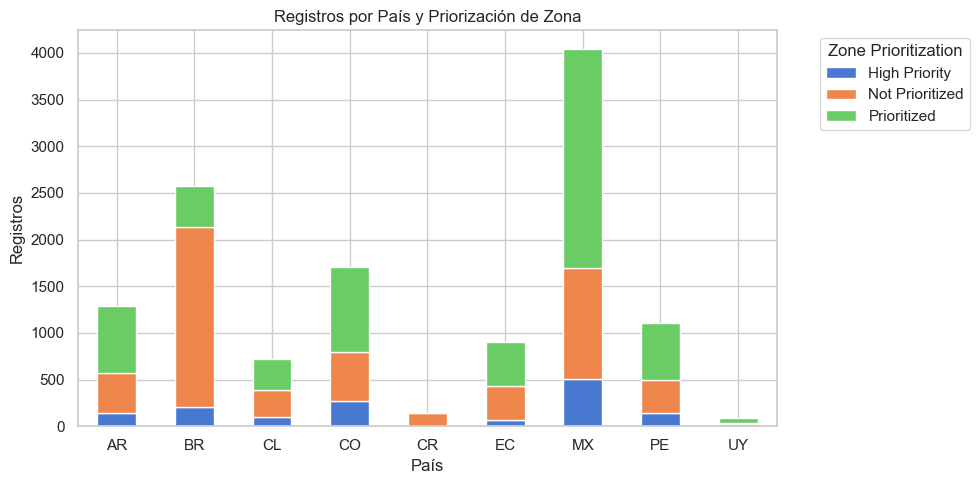

In [6]:
grouped = df.groupby(['COUNTRY', 'ZONE_PRIORITIZATION']).size().unstack(fill_value=0)

grouped.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Registros por País y Priorización de Zona')
plt.xlabel('País')
plt.ylabel('Registros')
plt.xticks(rotation=0)
plt.legend(title='Zone Prioritization', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
df.isnull().sum()

COUNTRY                  0
CITY                     0
ZONE                     0
ZONE_TYPE                0
ZONE_PRIORITIZATION      0
METRIC                   0
L8W_ROLL               113
L7W_ROLL               107
L6W_ROLL               111
L5W_ROLL               106
L4W_ROLL                98
L3W_ROLL                72
L2W_ROLL                55
L1W_ROLL                43
L0W_ROLL                 0
dtype: int64

## 02 Exploración de Métricas

In [8]:
metric_counts = df['METRIC'].value_counts()
print(f"Métricas distintas: {df['METRIC'].nunique()}")
print()
print(metric_counts)

Métricas distintas: 13

METRIC
Gross Profit UE                                   1911
Non-Pro PTC > OP                                   977
% Restaurants Sessions With Optimal Assortment     966
Pro Adoption (Last Week Status)                    961
Restaurants SST > SS CVR                           958
Restaurants SS > ATC CVR                           958
Retail SST > SS CVR                                946
% PRO Users Who Breakeven                          941
Perfect Orders                                     934
Lead Penetration                                   931
MLTV Top Verticals Adoption                        918
Restaurants Markdowns / GMV                        887
Turbo Adoption                                     285
Name: count, dtype: int64


In [9]:
metrics_per_zone = df.groupby(['COUNTRY', 'CITY', 'ZONE'])['METRIC'].nunique()
n_metrics = df['METRIC'].nunique()

print(f"Zonas con TODAS las métricas ({n_metrics}): {(metrics_per_zone == n_metrics).sum()}")
print(f"Zonas con métricas incompletas: {(metrics_per_zone < n_metrics).sum()}")
print()
print("Distribución de métricas por zona:")
metrics_per_zone.value_counts().sort_index()

Zonas con TODAS las métricas (13): 285
Zonas con métricas incompletas: 695

Distribución de métricas por zona:


METRIC
1       5
2       6
3       1
4       4
5       6
6       8
7       6
8       9
9      13
10     17
11     50
12    570
13    285
Name: count, dtype: int64

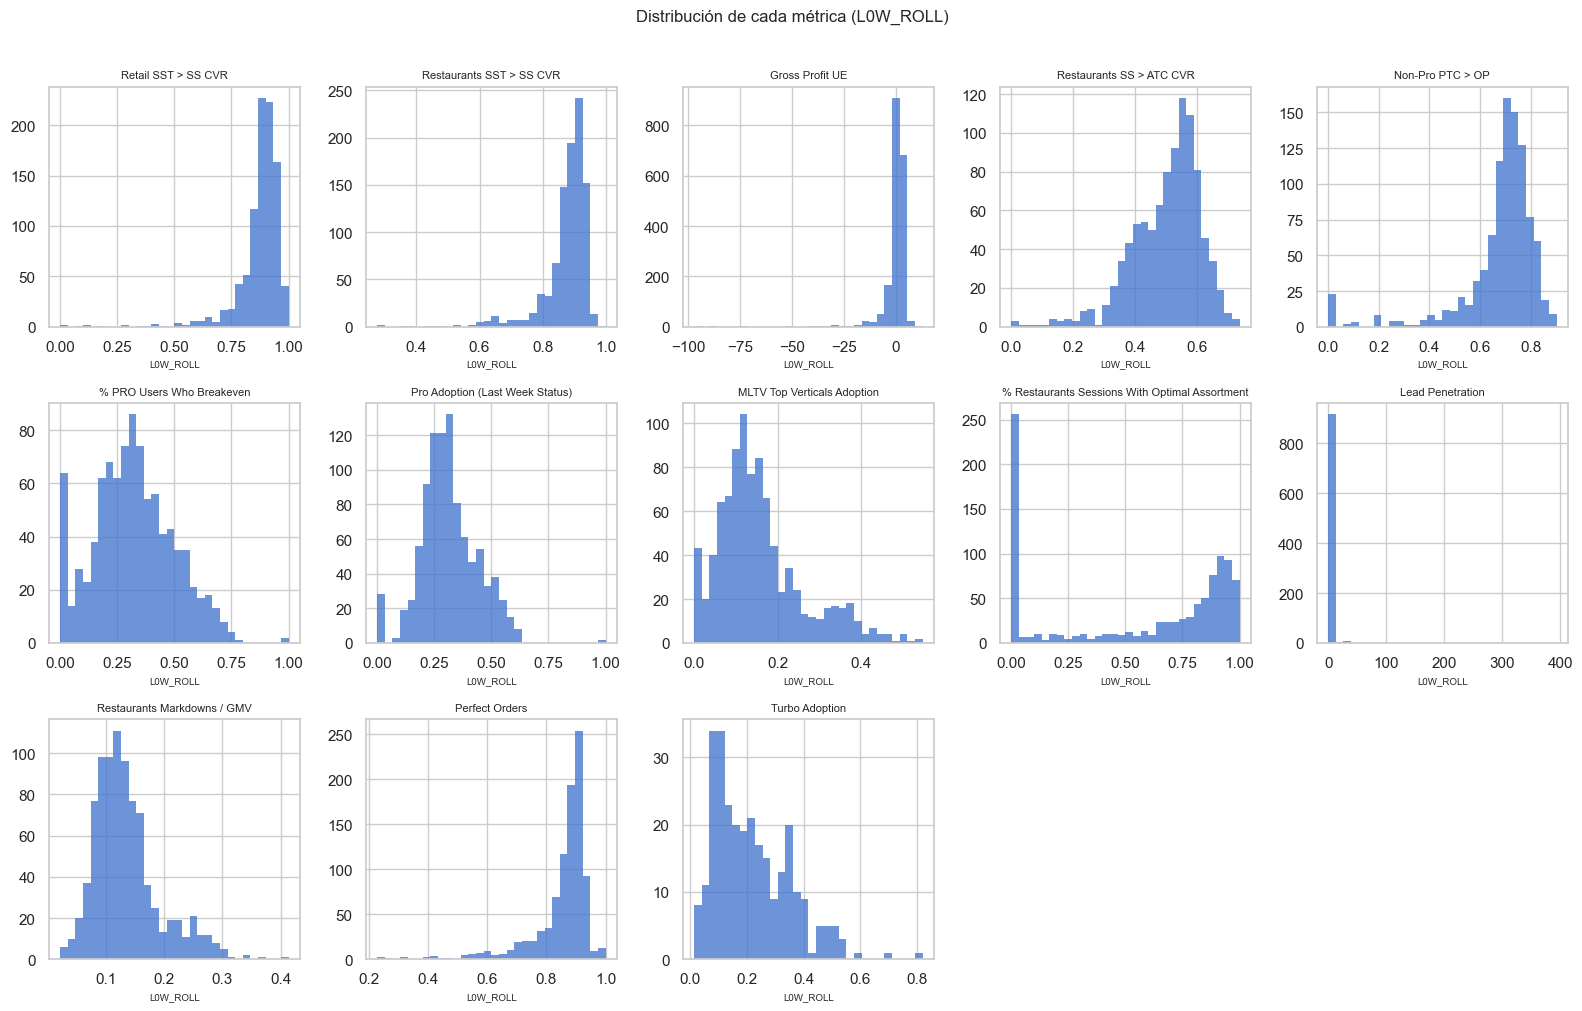

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()
xd = enumerate(df['METRIC'].unique())
for i, metric in enumerate(df['METRIC'].unique()):
    ax = axes[i]
    data = df[df['METRIC'] == metric]['L0W_ROLL'].dropna()
    ax.hist(data, bins=30, edgecolor='none', alpha=0.8)
    ax.set_title(metric, fontsize=8, wrap=True)
    ax.set_xlabel('L0W_ROLL', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de cada métrica (L0W_ROLL)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
df.groupby('METRIC')['L0W_ROLL'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
METRIC,,,,,,,,
% PRO Users Who Breakeven,941.0,0.321,0.175,0.000,0.200,0.316,0.436,1.000
% Restaurants Sessions With Optimal Assortment,966.0,0.558,0.392,0.000,0.013,0.739,0.908,1.000
Gross Profit UE,1911.0,-0.186,7.050,-97.134,-0.721,1.080,2.455,12.843
Lead Penetration,931.0,1.444,15.303,0.004,0.070,0.146,0.267,393.900
MLTV Top Verticals Adoption,918.0,0.158,0.104,0.000,0.090,0.135,0.196,0.547
Non-Pro PTC > OP,977.0,0.678,0.157,0.000,0.657,0.714,0.763,0.901
Perfect Orders,934.0,0.853,0.101,0.227,0.839,0.887,0.908,1.000
Pro Adoption (Last Week Status),961.0,0.315,0.126,0.000,0.239,0.303,0.386,1.000
Restaurants Markdowns / GMV,887.0,0.135,0.057,0.022,0.097,0.124,0.158,0.414


In [12]:
pivot = df.pivot_table(
    index=['COUNTRY','CITY','ZONE','ZONE_TYPE','ZONE_PRIORITIZATION'],
    columns='METRIC',
    values='L0W_ROLL'
)
pivot.columns.name = None

In [13]:
pivot.head()

% PRO Users Who Breakeven  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                              
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized                       0.202605   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized                       0.160888   
        Bariloche    BARILOCHE_CENTRO     Non Wealthy Not Prioritized                       0.047619   
        Buenos Aires Avellaneda - Sarandi Non Wealthy High Priority                         0.285417   
                     BERAZATEGUI          Non Wealthy Prioritized                           0.240175   

                                                                           % Restaurants Sessions With Optimal Assortment  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                                                   
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized                                            0.180863   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized                                            0.119665   
        Bariloche    BARILOCHE_CENTRO     Non Wealthy Not Prioritized                                            0.000000   
        Buenos Aires Avellaneda - Sarandi Non Wealthy High Priority                                              0.860468   
                     BERAZATEGUI          Non Wealthy Prioritized                                                0.151187   

                                                                           Gross Profit UE  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                    
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized            -0.785199   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized            -1.072561   
        Bariloche    BARILOCHE_CENTRO     Non Wealthy Not Prioritized             2.993454   
        Buenos Aires Avellaneda - Sarandi Non Wealthy High Priority              -1.126025   
                     BERAZATEGUI          Non Wealthy Prioritized                -2.542719   

                                                                           Lead Penetration  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                     
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized              0.216466   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized              0.110523   
        Bariloche    BARILOCHE_CENTRO     Non Wealthy Not Prioritized              0.248512   
        Buenos Aires Avellaneda - Sarandi Non Wealthy High Priority                0.287480   
                     BERAZATEGUI          Non Wealthy Prioritized                  0.170810   

                                                                           MLTV Top Verticals Adoption  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                                
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized                         0.091653   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized                         0.058602   
        Bariloche    BARILOCHE_CENTRO     Non Wealthy Not Prioritized                         0.040600   
        Buenos Aires Avellaneda - Sarandi Non Wealthy High Priority                           0.180600   
                     BERAZATEGUI          Non Wealthy Prioritized                             0.118152   

                                                                           Non-Pro PTC > OP  \
COUNTRY CITY         ZONE                 ZONE_TYPE   ZONE_PRIORITIZATION                     
AR      Bahia Blanca BAHIA_BLANCA_NORTE   Non Wealthy Not Prioritized              0.728519   
                     BAHIA_BLANCA_SUR     Non Wealthy Not Prioritized              0.755236   
        Bariloche    B

## 03 Tools development

Cada celda prototipa la lógica de una tool que el agente invocará para responder queries en lenguaje natural.

| Tool | Query de ejemplo |
|---|---|
| `get_top_zones` | "¿Cuáles son las 5 zonas con mayor Lead Penetration?" |
| `compare_segments` | "Compara Perfect Order entre Wealthy y Non Wealthy en México" |
| `get_zone_trend` | "Muestra la evolución de Gross Profit UE en Chapinero" |
| `aggregate_metric` | "¿Cuál es el promedio de Lead Penetration por país?" |
| `find_zones_multi_criteria` | "Zonas con alto Lead Penetration pero bajo Perfect Order" |
| `explain_trend` | "Zonas que más crecen en 5 semanas y por qué" |
| `search_zone` | Búsqueda fuzzy por nombre parcial |
| `list_metrics` | Catálogo de métricas para resolver lenguaje ambiguo |

In [14]:
# mejores zonas por metrica
def get_top_zones(metric: str, n: int = 5, direction: str = 'desc',
                  country: str = None, zone_type: str = None, week: str = 'L0W_ROLL'):
    mask = df['METRIC'] == metric
    if country:
        mask &= df['COUNTRY'] == country
    if zone_type:
        mask &= df['ZONE_TYPE'] == zone_type

    result = df[mask][['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', week]]\
        .dropna(subset=[week])\
        .sort_values(week, ascending=(direction == 'asc'))\
        .head(n)\
        .reset_index(drop=True)
    result.columns = ['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'value']
    return result

get_top_zones('Lead Penetration', n=5)

,COUNTRY,CITY,ZONE,ZONE_TYPE,ZONE_PRIORITIZATION,value
0,EC,Quito,Sur de Quito,Non Wealthy,High Priority,393.9
1,EC,Quito,Valle de los Chillos,Non Wealthy,High Priority,158.6
2,EC,Quito,Antiguo Aeropuerto,Non Wealthy,Prioritized,141.3
3,EC,Quito,Vicentina- Floresta,Non Wealthy,Prioritized,87.8
4,EC,Guayaquil,Via la Costa Oeste,Wealthy,Prioritized,57.2


In [15]:
# comparación de segmentos

def compare_segments(metric: str, group_by: str, filters: dict = {}):
    mask = df['METRIC'] == metric
    for col, val in filters.items():
        mask &= df[col] == val

    result = df[mask].groupby(group_by)['L0W_ROLL'].agg(
        zonas='count',
        promedio='mean',
        mediana='median',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        minimo='min',
        maximo='max'
    ).round(4)
    return result

compare_segments('Perfect Orders', group_by='ZONE_TYPE', filters={'COUNTRY': 'MX'})

,zonas,promedio,mediana,p25,p75,minimo,maximo
ZONE_TYPE,,,,,,,
Non Wealthy,228,0.8666,0.8917,0.8568,0.9121,0.2419,1.0000
Wealthy,74,0.9043,0.9051,0.8931,0.9192,0.8311,0.9513


In [16]:
# tendencia temporal por zona y métrica

def get_zone_trend(zone: str, metric: str, n_weeks: int = 8):
    weeks = ROLL_COLS[-(n_weeks + 1):]  # +1 para tener el punto de partida

    mask = (df['ZONE'].str.contains(zone, case=False, na=False)) & (df['METRIC'] == metric)
    rows = df[mask]

    if rows.empty:
        return f"No se encontró zona '{zone}' con métrica '{metric}'"

    result = rows[['COUNTRY', 'CITY', 'ZONE'] + weeks].set_index(['COUNTRY', 'CITY', 'ZONE'])

    # Visualización
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    for idx, row in result.iterrows():
        label = f"{idx[2]} ({idx[0]})"
        values = row.dropna()
        ax.plot(values.index, values.values, marker='o', label=label)

    ax.set_title(f'{metric} — Tendencia temporal')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Valor')
    ax.legend()
    plt.tight_layout()
    plt.show()
    """

    return result.round(4)

get_zone_trend('Chapinero', 'Gross Profit UE')

L8W_ROLL  L7W_ROLL  L6W_ROLL  L5W_ROLL  L4W_ROLL  \
COUNTRY CITY   ZONE                                                          
CO      Bogota Chapinero    2.9042    3.0638    3.1681    3.1921    3.1475   
               Chapinero    2.9042    3.0638    3.1681    3.1921    3.1475   

                          L3W_ROLL  L2W_ROLL  L1W_ROLL  L0W_ROLL  
COUNTRY CITY   ZONE                                               
CO      Bogota Chapinero    3.2522     3.357    3.4506    2.9869  
               Chapinero    3.2522     3.357    3.4506    2.9869

In [17]:
# agregación de métricas por segmento

def aggregate_metric(metric: str, group_by: str | list, agg_func: str = 'mean', filters: dict = {}):
    mask = df['METRIC'] == metric
    for col, val in filters.items():
        mask &= df[col] == val

    agg_map = {'mean': 'mean', 'median': 'median', 'sum': 'sum', 'count': 'count'}
    result = df[mask].groupby(group_by)['L0W_ROLL']\
        .agg(agg_map.get(agg_func, 'mean'))\
        .round(4)\
        .sort_values(ascending=False)\
        .reset_index()
    result.columns = [group_by, f'{agg_func}_{metric}'] if isinstance(group_by, str) else list(result.columns)
    return result

aggregate_metric('Lead Penetration', group_by='COUNTRY', agg_func='mean')

,COUNTRY,mean_Lead Penetration
0,EC,15.1382
1,PE,0.9189
2,CO,0.5436
3,CL,0.2644
4,AR,0.2612
5,MX,0.2317
6,BR,0.1981
7,UY,0.1136
8,CR,0.0473


In [18]:
# búsqueda de zonas que cumplen múltiples criterios en distintas métricas

def find_zones_multi_criteria(criteria: list):
    base_mask = pd.Series([True] * len(pivot), index=pivot.index)

    for c in criteria:
        metric = c['metric']
        direction = c['direction']  # 'high' o 'low'
        pct = c.get('threshold_pct', 0.75 if direction == 'high' else 0.25)

        if metric not in pivot.columns:
            print(f"  ⚠ Métrica '{metric}' no encontrada")
            continue

        threshold = pivot[metric].quantile(pct)
        if direction == 'high':
            base_mask &= pivot[metric] >= threshold
        else:
            base_mask &= pivot[metric] <= threshold

    result = pivot[base_mask].reset_index()

    id_cols = ['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION']
    metric_cols = [c['metric'] for c in criteria if c['metric'] in pivot.columns]

    return result[id_cols + metric_cols].round(4)

find_zones_multi_criteria([
    {'metric': 'Lead Penetration', 'direction': 'high'},
    {'metric': 'Perfect Orders',   'direction': 'low'}
])

,COUNTRY,CITY,ZONE,ZONE_TYPE,ZONE_PRIORITIZATION,Lead Penetration,Perfect Orders
0,AR,Buenos Aires,PILAR,Non Wealthy,Prioritized,0.2765,0.6841
1,AR,San Fernando,Catamarca,Non Wealthy,Not Prioritized,0.4056,0.7059
2,BR,Campinas,SP - VCP - Jardim Itatinga,Non Wealthy,Not Prioritized,2.4000,0.5760
3,BR,Campinas,SP - VCP - Jardim Santa Cruz,Non Wealthy,Not Prioritized,3.1000,0.6192
4,BR,Campinas,SP - VCP - Jardim Santa Lúcia,Non Wealthy,Not Prioritized,1.1000,0.7327
5,BR,Campo Grande,Campo Grande Expansión,Non Wealthy,Not Prioritized,0.3106,0.8021
6,BR,Grande São Paulo,SP - GRU - Centro,Non Wealthy,Not Prioritized,0.6186,0.5853
7,BR,Grande São Paulo,SP - SBC - Baeta/Santo André,Non Wealthy,Prioritized,0.3615,0.8097
8,BR,Joinville,MP Atiradores JOI,Non Wealthy,Not Prioritized,0.6000,0.5429
9,BR,Jundiai,Varzea Paulista,Non Wealthy,Not Prioritized,3.0000,0.3908


In [19]:
# explicación de tendencias

def explain_trend(n_weeks: int = 5, top_n: int = 10, filters: dict = {}):
    start_col = ROLL_COLS[-(n_weeks + 1)]  # semana de inicio
    end_col   = 'L0W_ROLL'

    mask = df[start_col].notna() & df[end_col].notna()
    for col, val in filters.items():
        mask &= df[col] == val

    base = df[mask].copy()
    base['growth_abs'] = base[end_col] - base[start_col]
    base['growth_pct'] = (base['growth_abs'] / base[start_col].abs()) * 100

    # Top zonas crecientes por métrica
    top_growing = base.sort_values('growth_pct', ascending=False)\
        [['COUNTRY','CITY','ZONE','METRIC', start_col, end_col, 'growth_pct']]\
        .head(top_n).round(3)

    # Para las zonas top, ver si otras métricas también crecieron (posible causa)
    top_zones = top_growing['ZONE'].unique()
    related = df[df['ZONE'].isin(top_zones)]\
        .groupby(['ZONE','METRIC'])['growth_pct'].first() if 'growth_pct' in df.columns else None

    return top_growing

explain_trend(n_weeks=5, top_n=10)

,COUNTRY,CITY,ZONE,METRIC,L5W_ROLL,L0W_ROLL,growth_pct
7612,EC,Manta,Jesus de Nazaret,% PRO Users Who Breakeven,0.0,0.250,inf
6841,PE,Cajamarca,Baños del Inca,% Restaurants Sessions With Optimal Assortment,0.0,0.030,inf
8050,BR,Rio De Janeiro,Oswaldo Cruz,% Restaurants Sessions With Optimal Assortment,0.0,0.000,inf
4175,MX,Lazaro Cardenas,LCS Puerto,MLTV Top Verticals Adoption,0.0,0.037,inf
7918,BR,Florianopolis,SC - FLN - Coqueiros,MLTV Top Verticals Adoption,0.0,0.054,inf
3681,CO,Bello,Popular,% PRO Users Who Breakeven,0.0,1.000,inf
5463,BR,Rio De Janeiro,Caxias,MLTV Top Verticals Adoption,0.0,0.080,inf
1537,MX,Rio Verde,RVE Rio Verde El Manantial,Non-Pro PTC > OP,0.0,0.200,inf
11103,AR,San Luis,SAN_LUIS,% Restaurants Sessions With Optimal Assortment,0.0,0.000,inf
1654,BR,Bauru,FS Vila Bonfim/Vila Universitária/Higienópolis...,Non-Pro PTC > OP,0.0,0.200,inf


In [20]:
# Para facilitar la interpretación

def list_metrics(with_descriptions: bool = True):
    metric_descriptions = {
        '% PRO Users Who Breakeven': 'Usuarios Pro cuyo valor generado cubre el costo de membresía / Total usuarios Pro',
        '% Restaurants Sessions With Optimal Assortment': 'Sesiones con mínimo 40 restaurantes / Total sesiones',
        'Gross Profit UE': 'Margen bruto de ganancia / Total de órdenes',
        'Lead Penetration': 'Tiendas habilitadas / (leads + habilitadas + salidas)',
        'MLTV Top Verticals Adoption': 'Usuarios con órdenes en diferentes verticales / Total usuarios',
        'Non-Pro PTC > OP': 'Conversión No Pro de "Proceed to Checkout" a "Order Placed"',
        'Perfect Orders': 'Órdenes sin cancelaciones, defectos o demora / Total órdenes',
        'Pro Adoption': 'Usuarios suscripción Pro / Total usuarios Rappi',
        'Restaurants Markdowns / GMV': 'Descuentos totales en restaurantes / GMV Restaurantes',
        'Restaurants SS > ATC CVR': 'Conversión en restaurantes de "Select Store" a "Add to Cart"',
        'Restaurants SST > SS CVR': 'Usuarios que seleccionan un restaurante de la lista presentada',
        'Retail SST > SS CVR': 'Usuarios que seleccionan un supermercado de la lista presentada',
        'Turbo Adoption': 'Usuarios comprando en Turbo / Usuarios con tiendas turbo disponible',
    }
    metrics_in_data = df['METRIC'].unique().tolist()

    if with_descriptions:
        return {m: metric_descriptions.get(m, 'Sin descripción') for m in sorted(metrics_in_data)}
    return sorted(metrics_in_data)

for metric, desc in list_metrics().items():
    print(f"• {metric}\n  {desc}\n")

• % PRO Users Who Breakeven
  Usuarios Pro cuyo valor generado cubre el costo de membresía / Total usuarios Pro

• % Restaurants Sessions With Optimal Assortment
  Sesiones con mínimo 40 restaurantes / Total sesiones

• Gross Profit UE
  Margen bruto de ganancia / Total de órdenes

• Lead Penetration
  Tiendas habilitadas / (leads + habilitadas + salidas)

• MLTV Top Verticals Adoption
  Usuarios con órdenes en diferentes verticales / Total usuarios

• Non-Pro PTC > OP
  Conversión No Pro de "Proceed to Checkout" a "Order Placed"

• Perfect Orders
  Órdenes sin cancelaciones, defectos o demora / Total órdenes

• Pro Adoption (Last Week Status)
  Sin descripción

• Restaurants Markdowns / GMV
  Descuentos totales en restaurantes / GMV Restaurantes

• Restaurants SS > ATC CVR
  Conversión en restaurantes de "Select Store" a "Add to Cart"

• Restaurants SST > SS CVR
  Usuarios que seleccionan un restaurante de la lista presentada

• Retail SST > SS CVR
  Usuarios que seleccionan un superm

## 04 Insights

In [21]:
df['wow_l1_l0'] = (df['L0W_ROLL'] - df['L1W_ROLL']) / df['L1W_ROLL'].abs()
df['wow_l2_l1'] = (df['L1W_ROLL'] - df['L2W_ROLL']) / df['L2W_ROLL'].abs()
df['wow_l3_l2'] = (df['L2W_ROLL'] - df['L3W_ROLL']) / df['L3W_ROLL'].abs()

ANOMALY_THRESHOLD = 0.10

anomalies = df[df['wow_l1_l0'].abs() > ANOMALY_THRESHOLD]
print(f"Registros con anomalía la última semana: {len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)")
print(f"  → Deterioro (>{ANOMALY_THRESHOLD*100:.0f}%): {(df['wow_l1_l0'] < -ANOMALY_THRESHOLD).sum()}")
print(f"  → Mejora   (>{ANOMALY_THRESHOLD*100:.0f}%):  {(df['wow_l1_l0'] > ANOMALY_THRESHOLD).sum()}")

Registros con anomalía la última semana: 2473 (19.7%)
  → Deterioro (>10%): 1542
  → Mejora   (>10%):  931


In [22]:
# Top anomalías: las zonas con mayor deterioro la última semana
top_declines = df[df['wow_l1_l0'] < -ANOMALY_THRESHOLD]\
    .sort_values('wow_l1_l0')[['COUNTRY','CITY','ZONE','METRIC','L1W_ROLL','L0W_ROLL','wow_l1_l0']]\
    .head(10)

top_declines['wow_l1_l0'] = (top_declines['wow_l1_l0'] * 100).round(1).astype(str) + '%'
top_declines

,COUNTRY,CITY,ZONE,METRIC,L1W_ROLL,L0W_ROLL,wow_l1_l0
1977,AR,Mendoza,GRAN_MENDOZA_GODOY,Gross Profit UE,0.001261,-1.693752,-134401.5%
1109,AR,Mendoza,GRAN_MENDOZA_GODOY,Gross Profit UE,0.001261,-1.693752,-134401.5%
1753,AR,Buenos Aires,Villa Ballester,Gross Profit UE,-0.000336,-0.165987,-49308.4%
1307,AR,Buenos Aires,Villa Ballester,Gross Profit UE,-0.000336,-0.165987,-49308.4%
2117,PE,Arequipa,Misti Norte,Gross Profit UE,-0.002615,-0.818723,-31211.1%
1399,PE,Arequipa,Misti Norte,Gross Profit UE,-0.002615,-0.818723,-31211.1%
1057,MX,Hermosillo,Hmo_Progreso,Gross Profit UE,-0.000894,-0.175442,-19523.6%
1813,MX,Hermosillo,Hmo_Progreso,Gross Profit UE,-0.000894,-0.175442,-19523.6%
715,CL,Quillota,Quillota,Gross Profit UE,-0.011520,-1.368852,-11782.8%
1474,CL,Quillota,Quillota,Gross Profit UE,-0.011520,-1.368852,-11782.8%


In [23]:
# Deterioro consistente = cada semana más baja que la anterior (3+ semanas)
df['declining_3w'] = (
    (df['L0W_ROLL'] < df['L1W_ROLL']) &
    (df['L1W_ROLL'] < df['L2W_ROLL']) &
    (df['L2W_ROLL'] < df['L3W_ROLL'])
)
df['declining_5w'] = df['declining_3w'] & (
    (df['L3W_ROLL'] < df['L4W_ROLL']) &
    (df['L4W_ROLL'] < df['L5W_ROLL'])
)

print(f"Zonas en deterioro 3+ semanas: {df['declining_3w'].sum()} ({df['declining_3w'].mean()*100:.1f}%)")
print(f"Zonas en deterioro 5+ semanas: {df['declining_5w'].sum()} ({df['declining_5w'].mean()*100:.1f}%)")

Zonas en deterioro 3+ semanas: 1705 (13.6%)
Zonas en deterioro 5+ semanas: 454 (3.6%)


In [24]:
declining_by_metric = df[df['declining_3w']].groupby('METRIC').size().sort_values(ascending=False)
total_by_metric = df.groupby('METRIC').size()

trend_summary = pd.DataFrame({
    'declining_zones': declining_by_metric,
    'total_zones': total_by_metric,
    'pct_declining': (declining_by_metric / total_by_metric * 100).round(1)
}).dropna().sort_values('pct_declining', ascending=False)

trend_summary

,declining_zones,total_zones,pct_declining
METRIC,,,
MLTV Top Verticals Adoption,293,918,31.9
Restaurants SS > ATC CVR,296,958,30.9
Restaurants Markdowns / GMV,193,887,21.8
Lead Penetration,172,931,18.5
Turbo Adoption,51,285,17.9
% PRO Users Who Breakeven,126,941,13.4
Perfect Orders,125,934,13.4
Restaurants SST > SS CVR,105,958,11.0
Non-Pro PTC > OP,90,977,9.2


In [25]:
# Magnitud del deterioro acumulado en las zonas con tendencia negativa
declining = df[df['declining_3w']].copy()
declining['total_decline_3w'] = (declining['L0W_ROLL'] - declining['L3W_ROLL']) / declining['L3W_ROLL'].abs()

print("Magnitud del deterioro acumulado (3 semanas) por métrica:")
declining.groupby('METRIC')['total_decline_3w'].describe()[['mean','min','25%','50%']].round(3)

Magnitud del deterioro acumulado (3 semanas) por métrica:


,mean,min,25%,50%
METRIC,,,,
% PRO Users Who Breakeven,-0.134,-0.707,-0.149,-0.081
% Restaurants Sessions With Optimal Assortment,-0.221,-1.000,-0.272,-0.042
Gross Profit UE,-1.344,-5.586,-1.769,-0.878
Lead Penetration,-0.092,-0.635,-0.120,-0.058
MLTV Top Verticals Adoption,-0.138,-1.000,-0.137,-0.081
Non-Pro PTC > OP,-0.151,-1.000,-0.090,-0.045
Perfect Orders,-0.069,-0.389,-0.107,-0.045
Pro Adoption (Last Week Status),-0.226,-0.671,-0.279,-0.196
Restaurants Markdowns / GMV,-0.172,-0.575,-0.280,-0.107


In [26]:
# Peer group: mismo COUNTRY + ZONE_TYPE + METRIC
df['peer_group'] = df['COUNTRY'] + '_' + df['ZONE_TYPE']

peer_stats = df.groupby(['peer_group', 'METRIC'])['L0W_ROLL'].agg(
    peer_mean='mean',
    peer_std='std',
    peer_n='count',
    peer_p25=lambda x: x.quantile(0.25),
    peer_p75=lambda x: x.quantile(0.75)
).reset_index()

df = df.merge(peer_stats, on=['peer_group', 'METRIC'])
df['z_score'] = (df['L0W_ROLL'] - df['peer_mean']) / df['peer_std'].replace(0, np.nan)
df['percentile_in_peer'] = df.groupby(['peer_group', 'METRIC'])['L0W_ROLL']\
                              .transform(lambda x: x.rank(pct=True))

print("Tamaño de peer groups:")
peer_stats.groupby('peer_group')['peer_n'].describe().round(0)

Tamaño de peer groups:


,count,mean,std,min,25%,50%,75%,max
peer_group,,,,,,,,
AR_Non Wealthy,13.0,80.0,27.0,28.0,78.0,78.0,78.0,156.0
AR_Wealthy,13.0,19.0,5.0,14.0,18.0,18.0,18.0,36.0
BR_Non Wealthy,12.0,166.0,48.0,117.0,148.0,160.0,164.0,311.0
BR_Wealthy,12.0,48.0,13.0,41.0,45.0,45.0,45.0,90.0
CL_Non Wealthy,13.0,42.0,15.0,11.0,40.0,41.0,42.0,84.0
CL_Wealthy,13.0,14.0,4.0,8.0,13.0,13.0,13.0,26.0
CO_Non Wealthy,13.0,95.0,28.0,67.0,87.0,90.0,91.0,186.0
CO_Wealthy,13.0,36.0,10.0,29.0,34.0,34.0,34.0,68.0
CR_Non Wealthy,12.0,12.0,4.0,8.0,9.0,12.0,13.0,22.0


In [27]:
small_peers = peer_stats[peer_stats['peer_n'] < 5]
print(f"Peer groups con < 5 zonas: {len(small_peers)} de {len(peer_stats)}")
print()
print("El agente debe advertir cuando el peer group sea pequeño:")
small_peers[['peer_group','METRIC','peer_n']].sort_values('peer_n')

Peer groups con < 5 zonas: 1 de 203

El agente debe advertir cuando el peer group sea pequeño:


,peer_group,METRIC,peer_n
202,UY_Non Wealthy,Turbo Adoption,3


In [28]:
# Zonas outliers: z_score extremo (bajo rendimiento vs peers)
bottom_performers = df[df['z_score'] < -2][['COUNTRY','CITY','ZONE','ZONE_TYPE','METRIC',
                                              'L0W_ROLL','peer_mean','percentile_in_peer','z_score']]\
    .sort_values('z_score').head(10).round(3)

print(f"Zonas con z_score < -2 (bottom performers vs peers): {(df['z_score'] < -2).sum()}")
bottom_performers

Zonas con z_score < -2 (bottom performers vs peers): 395


,COUNTRY,CITY,ZONE,ZONE_TYPE,METRIC,L0W_ROLL,peer_mean,percentile_in_peer,z_score
11946,CO,Duitama,Duitama,Non Wealthy,Gross Profit UE,-89.401,-0.452,0.008,-8.121
2007,CO,Duitama,Duitama,Non Wealthy,Gross Profit UE,-89.401,-0.452,0.008,-8.121
12045,MX,La Piedad,LPD Centro,Non Wealthy,Retail SST > SS CVR,0.267,0.866,0.004,-7.774
48,AR,Buenos Aires,ESCOBAR,Non Wealthy,Retail SST > SS CVR,0.399,0.876,0.013,-7.609
790,AR,Posadas,Posadas,Non Wealthy,Gross Profit UE,-17.711,-1.100,0.010,-6.974
428,AR,Posadas,Posadas,Non Wealthy,Gross Profit UE,-17.711,-1.100,0.010,-6.974
4095,MX,Ciudad Guzman,CDG La Hacienda,Non Wealthy,Perfect Orders,0.242,0.867,0.004,-6.781
1250,PE,Mancora,Vichayito,Non Wealthy,Gross Profit UE,-97.134,-3.409,0.010,-6.718
571,PE,Mancora,Vichayito,Non Wealthy,Gross Profit UE,-97.134,-3.409,0.010,-6.718
1831,PE,Mancora,Vichayito,Non Wealthy,Non-Pro PTC > OP,0.000,0.720,0.013,-6.492


In [29]:
# Pivotear: una fila por zona, columnas = métricas (usando L0W_ROLL)
pivot = df.pivot_table(
    index=['COUNTRY','CITY','ZONE','ZONE_TYPE','ZONE_PRIORITIZATION'],
    columns='METRIC',
    values='L0W_ROLL'
)
pivot.columns.name = None

print(f"Zonas totales: {pivot.shape[0]}")
print(f"Zonas con TODAS las métricas: {pivot.dropna().shape[0]}")
print(f"Cobertura: {pivot.dropna().shape[0]/pivot.shape[0]*100:.1f}%")

Zonas totales: 980
Zonas con TODAS las métricas: 285
Cobertura: 29.1%


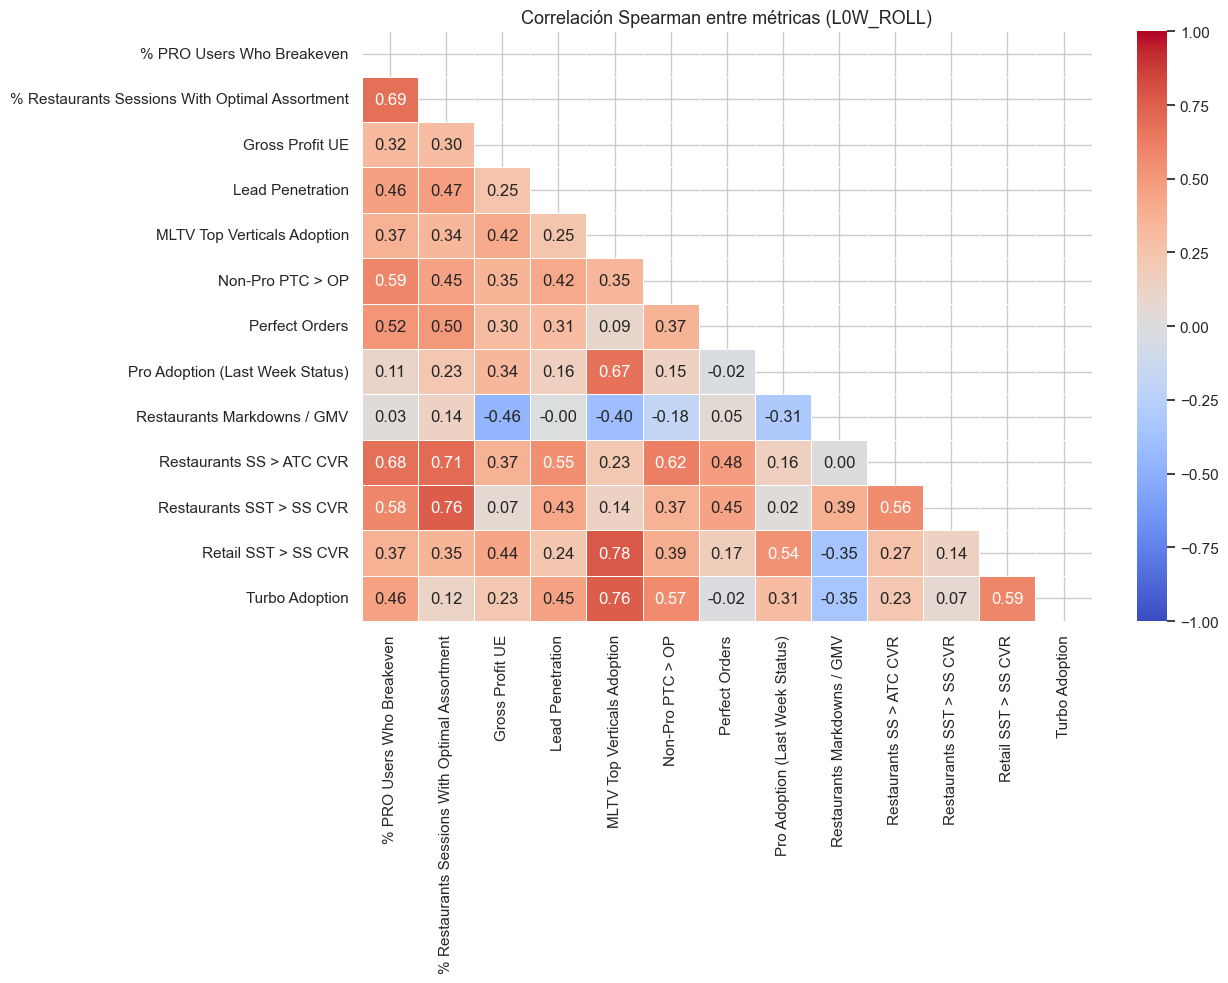

In [30]:
# Matriz de correlaciones entre métricas
corr_matrix = pivot.corr(method='spearman')  # Spearman es más robusto ante outliers

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlación Spearman entre métricas (L0W_ROLL)', fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
# Pares con correlación fuerte (|r| > 0.5) — candidatos a insights del agente
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['metric_a', 'metric_b', 'correlation']
corr_pairs = corr_pairs[
    (corr_pairs['metric_a'] < corr_pairs['metric_b']) &  # evitar duplicados
    (corr_pairs['correlation'].abs() > 0.5)
].sort_values('correlation', ascending=False)

print(f"Pares de métricas con |correlación| > 0.5:")
corr_pairs.round(3)

Pares de métricas con |correlación| > 0.5:


,metric_a,metric_b,correlation
63,MLTV Top Verticals Adoption,Retail SST > SS CVR,0.781
64,MLTV Top Verticals Adoption,Turbo Adoption,0.764
23,% Restaurants Sessions With Optimal Assortment,Restaurants SST > SS CVR,0.759
22,% Restaurants Sessions With Optimal Assortment,Restaurants SS > ATC CVR,0.709
1,% PRO Users Who Breakeven,% Restaurants Sessions With Optimal Assortment,0.686
9,% PRO Users Who Breakeven,Restaurants SS > ATC CVR,0.684
59,MLTV Top Verticals Adoption,Pro Adoption (Last Week Status),0.672
74,Non-Pro PTC > OP,Restaurants SS > ATC CVR,0.619
155,Retail SST > SS CVR,Turbo Adoption,0.590
5,% PRO Users Who Breakeven,Non-Pro PTC > OP,0.588


In [32]:
summary = {
    'detect_anomalies': {
        'registros_cubiertos': f"{df['wow_l1_l0'].notna().mean()*100:.1f}%",
        'hit_rate_10pct': f"{(df['wow_l1_l0'].abs() > 0.10).mean()*100:.1f}% de registros tienen anomalía",
        'nota': 'Threshold puede ajustarse por métrica según volatility calculada arriba'
    },
    'detect_declining_trends': {
        'registros_cubiertos': f"{df['declining_3w'].notna().mean()*100:.1f}%",
        'zonas_en_deterioro_3w': int(df['declining_3w'].sum()),
        'zonas_en_deterioro_5w': int(df['declining_5w'].sum()),
        'nota': 'Requiere L3W_ROLL no nulo → excluye zonas con < 6 semanas de datos'
    },
    'benchmark_zone': {
        'peer_groups_totales': int(peer_stats['peer_group'].nunique()),
        'peer_groups_chicos_menos_5': int(len(small_peers)),
        'peer_n_mediana': float(peer_stats['peer_n'].median()),
        'nota': 'Advertir al usuario si peer_n < 5'
    },
    'find_correlated_metrics': {
        'zonas_con_todas_metricas': int(pivot.dropna().shape[0]),
        'cobertura': f"{pivot.dropna().shape[0]/pivot.shape[0]*100:.1f}%",
        'pares_con_correlacion_fuerte': int(len(corr_pairs)),
        'nota': 'Usar pares de corr_pairs como insights precomputados'
    }
}

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "detect_anomalies": {
    "registros_cubiertos": "97.0%",
    "hit_rate_10pct": "19.7% de registros tienen anomalía",
    "nota": "Threshold puede ajustarse por métrica según volatility calculada arriba"
  },
  "detect_declining_trends": {
    "registros_cubiertos": "100.0%",
    "zonas_en_deterioro_3w": 1705,
    "zonas_en_deterioro_5w": 454,
    "nota": "Requiere L3W_ROLL no nulo → excluye zonas con < 6 semanas de datos"
  },
  "benchmark_zone": {
    "peer_groups_totales": 16,
    "peer_groups_chicos_menos_5": 1,
    "peer_n_mediana": 42.0,
    "nota": "Advertir al usuario si peer_n < 5"
  },
  "find_correlated_metrics": {
    "zonas_con_todas_metricas": 285,
    "cobertura": "29.1%",
    "pares_con_correlacion_fuerte": 17,
    "nota": "Usar pares de corr_pairs como insights precomputados"
  }
}
